In [1]:
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
       
import torch
import numpy as np
import warp as wp

# Initialize Warp
wp.config.verify_autograd_array_access = False
wp.config.verbose = False
wp.init()

from sphWarpCore import radiusSearchCompactHashMap, sphOperation_warp
from sphWarpCore.enumTypes import *

import matplotlib.pyplot as plt
from demo_util import *
from warpPlot import *

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [9]:
device = torch.device('cpu')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
targetNumNeighbors = 50
nx = 512
dim = 2
numParticles = nx**dim

warpOnly = False
periodic = True

kernel = KernelFunctions.Wendland2
supportMode = SupportScheme.Gather

markerSize = 8 if warpOnly else 2
gridVisualization = False 
gridResolution = 128
dx = 2.0 / nx

In [10]:
particleState, domain, adjacency, neighborhood, simulationState, measurements = prepData(nx, targetNumNeighbors, dim, device, periodic, warpOnly)
apparentVolume, crkDensity, crkState = computeCRKFactors(particleState, domain, kernel, adjacency = adjacency)

In [11]:
f_linear = particleState.positions[:,0] * 5 + 10
f_grad_x = torch.full_like(f_linear, 5.0)
f_grad_y = torch.zeros_like(f_linear)

linear_gradient_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties=OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain,
)

print("Linear Gradient (WarpSPH): ", linear_gradient_warp)

mean_error_x = torch.mean(torch.abs(linear_gradient_warp[:,0] - f_grad_x))
mean_error_y = torch.mean(torch.abs(linear_gradient_warp[:,1] - f_grad_y))

print("Mean Absolute Error in X Gradient: ", mean_error_x.item())
print("Mean Absolute Error in Y Gradient: ", mean_error_y.item())

Linear Gradient (WarpSPH):  tensor([[-8.2847e+02,  2.4741e+00],
        [-2.7063e+02,  4.5959e+00],
        [-3.0324e+01,  7.0590e-01],
        ...,
        [-4.8416e+01,  3.4005e+00],
        [-4.0694e+02,  2.7231e+01],
        [-8.0757e+02,  6.7110e+01]], device='cuda:0')
Mean Absolute Error in X Gradient:  5.035746097564697
Mean Absolute Error in Y Gradient:  0.19644632935523987


In [12]:
print("Testing Linear Interpolation with WarpSPH...")
print("Input Function: f(x,y) = 5x + 10", 'Min: ', torch.min(f_linear), "Max: ", torch.max(f_linear))
linear_interp = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties=OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Interpolate,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = None,
    domain = domain,
)
print("Linear Interpolation (WarpSPH): ", linear_interp, "Min: ", torch.min(linear_interp), "Max: ", torch.max(linear_interp))

Testing Linear Interpolation with WarpSPH...
Input Function: f(x,y) = 5x + 10 Min:  tensor(5.0050, device='cuda:0') Max:  tensor(14.9960, device='cuda:0')
Linear Interpolation (WarpSPH):  tensor([ 7.5763,  5.4282,  5.1012,  ..., 15.3602, 14.7253, 12.5210],
       device='cuda:0') Min:  tensor(4.8669, device='cuda:0') Max:  tensor(15.5258, device='cuda:0')


In [13]:
f = torch.randn(numParticles, device=device, dtype=torch.float32)

f_smoothed = f.clone()

for _ in range(4):
    f_smoothed = warpOperation(
        queryParticles = particleState,
        queryValues = f_smoothed,
        operationProperties = OperationProperties(
            kernel = kernel,
            supportMode = supportMode,
            operation = WarpOperation.Interpolate,
        ),
        adjacency = None,
        domain = domain,
    )

gradient_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_smoothed,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain,
)


if not warpOnly:
    gradient_diffSPH = SPHOperation(
        simulationState,
        quantity = f_smoothed,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        gradientMode=GradientMode.Difference,
        supportScheme = SupportScheme.Gather,
        correctionTerms= [],
        positiveDivergence=False
    )



In [14]:
from warpPlot import *

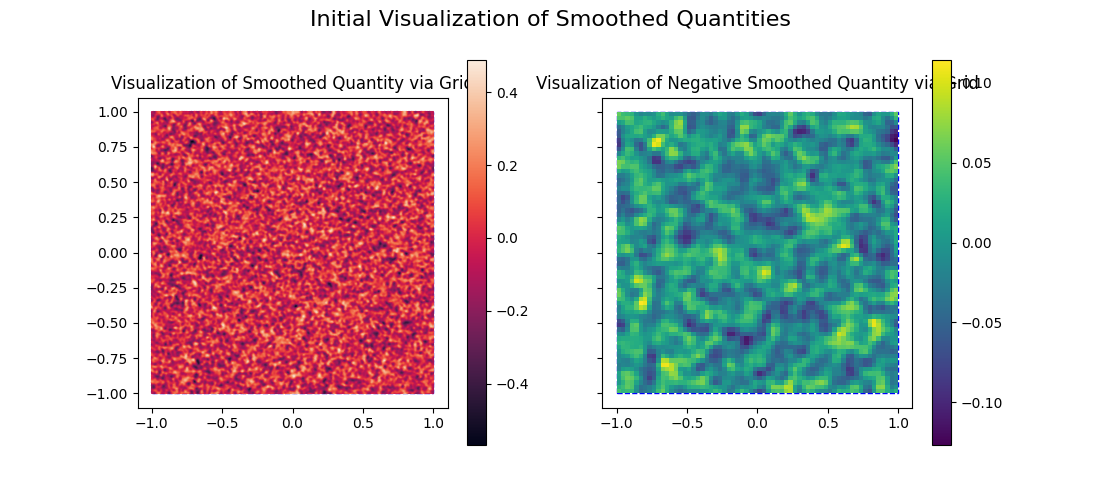

In [ ]:
plotter = visualize(
    particleState = particleState,
    domain = domain,
    quantities = {
        "A": f_smoothed,
        "B": -f_smoothed,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = ColorMap.rocket,
            markerSize = 0.1,
            midPoint = 'median',
            plotTitle = "Visualization of Smoothed Quantity via Grid",
            # gridVisualization = GridVisualization(
            #     resolution = 64,
            # ),
        ),
        "B": PlottingOptions(
            colorMap = ColorMap.viridis,
            markerSize = 0.1,
            midPoint = 'median',
            plotTitle = "Visualization of Negative Smoothed Quantity via Grid",
            gridVisualization = GridVisualization(
                resolution = 64,
            ),
        ),
    },
    figTitle = "Initial Visualization of Smoothed Quantities",
    mosaic = 'AB',
    figsize= (11,5),
    backend='pyvista',
    backendOptions = {
        'jupyter_backend': 'trame',
    }
)

In [18]:
import copy
from tqdm.autonotebook import tqdm
tempState = copy.deepcopy(particleState)
for i in tqdm(range(16), desc="Updating Visualization"):
    tempState.positions += 0.1 * torch.randn_like(tempState.positions)
    plotter.updateQuantities(
        {
            "A": f_smoothed,
            "B": -f_smoothed,
        },
        newParticleState = tempState,
        newOptions = {
            'A': {
                'colorMap': ColorMap.Spectral
            }
        },
    )
    

Updating Visualization:   0%|          | 0/16 [00:00<?, ?it/s]